In [4]:
import torch

inputs = torch.tensor(
    [[0.72, 0.45, 0.31],
     [0.75, 0.3, 0.55],
     [0.3, 0.8, 0.4],
     [0.85, 0.35, 0.6],
     [0.55, 0.15, 0.75],
     [0.25, 0.20, 0.85]]
)

#converted to input embeddings (assume after input block in transformer) here
words = ['Dream','big','and','work','for','it']

Magnitude of vectors

In [6]:
# Calculate the magnitude of each vector
magnitudes = torch.norm(inputs, dim=1)

# Print the magnitudes
print("Magnitudes of the vectors:" )
for word, magnitude in zip(words, magnitudes):
  print(f"{word}: {magnitude.item():.4f}")

Magnitudes of the vectors:
Dream: 0.9039
big: 0.9772
and: 0.9434
work: 1.0977
for: 0.9421
it: 0.9083


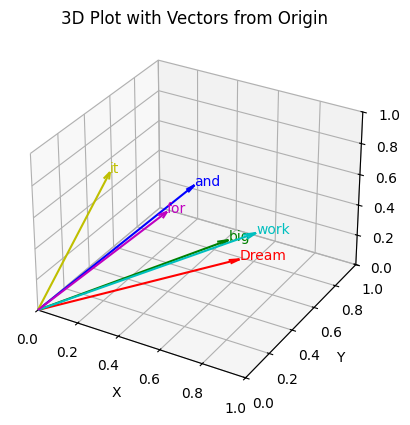

In [10]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
# Extract x, y, z coordinates
x_coords = inputs[:, 0].numpy()
y_coords = inputs[:, 1].numpy()
z_coords = inputs[:, 2].numpy()

# 3D plot with vectors from origin
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')


colors = ['r', 'g','b','c','m', 'y']

for x, y, z, word, color in zip(x_coords, y_coords, z_coords, words, colors):
    ax.quiver(0, 0, 0, x, y, z, color=color, arrow_length_ratio=0.05)
    ax.text(x, y, z, word, fontsize=10, color=color)

ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.set_xlim([0, 1])
ax.set_ylim([0, 1])
ax.set_zlim([0, 1])
ax.set_title('3D Plot with Vectors from Origin')
plt.show()

Dot product for attention scores between 2nd input token and all words

In [11]:
query = input[1] #"big"

attn_scores_2 = torch.empty(inputs.shape[0])
for i, x_i in enumerate(inputs):
  attn_scores_2[i] = torch.dot(x_i, query) #transpose not needed here

print(attn_scores_2)

tensor([0.8455, 0.9550, 0.6850, 1.0725, 0.8700, 0.7150])


normalizing the attention weighst - normal

In [14]:
attn_weights_2_tmp = attn_scores_2 / attn_scores_2.sum()
print(attn_weights_2_tmp)

print(attn_weights_2_tmp.sum())

tensor([0.1644, 0.1857, 0.1332, 0.2085, 0.1692, 0.1390])
tensor(1.)


softmaxx as it is better dominating as others might just be ratios rather. and also better for training and interpretation

In [18]:
import tensorflow as tf

attn_scores_2_tf = tf.convert_to_tensor(attn_scores_2.numpy())
attn_weights_2_tmp = tf.nn.softmax(attn_scores_2_tf)

print(attn_weights_2_tmp)
print(attn_weights_2_tmp.numpy().sum())

tf.Tensor([0.16327257 0.18216649 0.13906217 0.20487931 0.16732216 0.14329724], shape=(6,), dtype=float32)
0.99999994


numbers are being rounded off in softmax fn, thats why the 0.999

attention scores for all queries

In [19]:
attn_scores = inputs @ inputs.T #@ efficient matrix multiplication
print(attn_scores)

tensor([[0.8170, 0.8455, 0.7000, 0.9555, 0.6960, 0.5335],
        [0.8455, 0.9550, 0.6850, 1.0725, 0.8700, 0.7150],
        [0.7000, 0.6850, 0.8900, 0.7750, 0.5850, 0.5750],
        [0.9555, 1.0725, 0.7750, 1.2050, 0.9700, 0.7925],
        [0.6960, 0.8700, 0.5850, 0.9700, 0.8875, 0.8050],
        [0.5335, 0.7150, 0.5750, 0.7925, 0.8050, 0.8250]])


6 queries - (6x3)

6 embeddings - (6x3)


output 6x6 so just transpore of input x input^t

attention scores converted to attention weighst (normalize)

In [20]:
attn_weights = torch.softmax(attn_scores, dim=-1)
print(attn_weights)

tensor([[0.1752, 0.1803, 0.1559, 0.2013, 0.1553, 0.1320],
        [0.1633, 0.1822, 0.1391, 0.2049, 0.1673, 0.1433],
        [0.1654, 0.1629, 0.2000, 0.1783, 0.1474, 0.1460],
        [0.1638, 0.1841, 0.1367, 0.2102, 0.1662, 0.1391],
        [0.1487, 0.1769, 0.1330, 0.1955, 0.1800, 0.1658],
        [0.1391, 0.1668, 0.1450, 0.1803, 0.1825, 0.1862]])


all rows sum up to 1

context vector calc now (attention weights and input embeddings)

In [21]:
all_context_vecs = attn_weights @ inputs
print(all_context_vecs)

tensor([[0.5977, 0.3778, 0.5653],
        [0.5979, 0.3648, 0.5767],
        [0.5704, 0.3970, 0.5625],
        [0.6018, 0.3646, 0.5757],
        [0.5863, 0.3550, 0.5899],
        [0.5690, 0.3564, 0.5962]])


6 word - 6 context vectors

In [24]:
context_vec_2 = all_context_vecs[1]
print(context_vec_2)

tensor([0.5979, 0.3648, 0.5767])


add context vector to our inital plot to see the before and after

In [29]:
inputs = torch.cat((inputs, context_vec_2.unsqueeze(0)), dim=0)

words.append("context vector")

print("Updated Inputs tensor")
print(inputs)
print("Updated Words list")
print(words)

Updated Inputs tensor
tensor([[0.7200, 0.4500, 0.3100],
        [0.7500, 0.3000, 0.5500],
        [0.3000, 0.8000, 0.4000],
        [0.8500, 0.3500, 0.6000],
        [0.5500, 0.1500, 0.7500],
        [0.2500, 0.2000, 0.8500],
        [0.5979, 0.3648, 0.5767]])
Updated Words list
['Dream', 'big', 'and', 'work', 'for', 'it', 'context vector']


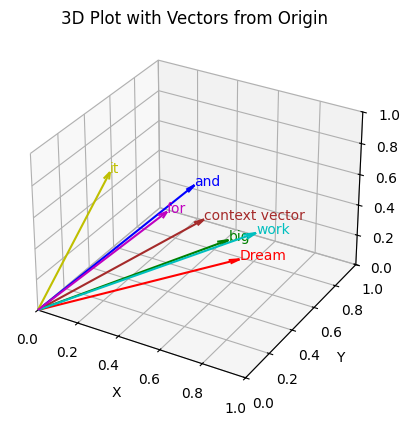

In [32]:
x_coords = inputs[:, 0].numpy()
y_coords = inputs[:, 1].numpy()
z_coords = inputs[:, 2].numpy()

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')


colors = ['r', 'g','b','c','m', 'y','brown']

for x, y, z, word, color in zip(x_coords, y_coords, z_coords, words, colors):
    ax.quiver(0, 0, 0, x, y, z, color=color, arrow_length_ratio=0.05)
    ax.text(x, y, z, word, fontsize=10, color=color)

ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.set_xlim([0, 1])
ax.set_ylim([0, 1])
ax.set_zlim([0, 1])
ax.set_title('3D Plot with Vectors from Origin')
plt.show()